# Graph Attribute Inspection

Analysis of node and edge attributes from the AS relationship graph:
- Value ranges and data types (to complete **Table 2**)
- Spearman correlations between features
- Distributions split by relationship type (P2P / C2P / P2C)
- Automatic conclusions

In [3]:
from pathlib import Path

data_path  = Path('/media/vale/KINGSTON/TESIS/data_2026')
nodes_file = data_path / 'nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv'
edges_file = data_path / 'edges_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv'

print('nodes exists:', nodes_file.exists())
print('edges exists:', edges_file.exists())

nodes exists: True
edges exists: True


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})

nodes_df = pd.read_csv(nodes_file)
edges_df = pd.read_csv(edges_file)

print(f"Nodes : {nodes_df.shape[0]:,} rows x {nodes_df.shape[1]} columns")
print(f"Edges : {edges_df.shape[0]:,} rows x {edges_df.shape[1]} columns")
print(f"\nEdge columns : {list(edges_df.columns)}")
print(f"\nEdge relationship distribution:")
rel_map = {0: 'P2P', 1: 'C2P', 2: 'P2C', -1: 'Unknown'}
print(edges_df['relationship'].map(rel_map).value_counts().to_string())

Nodes : 79,504 rows x 74 columns
Edges : 734,381 rows x 6 columns

Edge columns : ['src_id', 'dst_id', 'src_asn', 'dst_asn', 'weight', 'relationship']

Edge relationship distribution:
relationship
P2P        340512
C2P        159963
P2C        159963
Unknown     73943


## Table 2 — Attribute Summary

Min, max, mean, std, unique values and null% for every node attribute.

In [5]:
META_COLS = {'node_id', 'asn', 'country'}

rows = []
for col in nodes_df.columns:
    if col in META_COLS:
        continue
    s          = nodes_df[col]
    num_unique = int(s.nunique(dropna=True))
    null_pct   = float(s.isna().mean() * 100)

    if pd.api.types.is_numeric_dtype(s):
        mn  = float(s.min(skipna=True))
        mx  = float(s.max(skipna=True))
        mu  = float(s.mean(skipna=True))
        std = float(s.std(skipna=True))
        if num_unique == 2 and set(s.dropna().unique()).issubset({0, 1, 0.0, 1.0}):
            dtype_label = 'Binary'
        elif num_unique <= 20:
            dtype_label = f'Categorical ({num_unique} cat.)'
        else:
            rng = '[0,1]' if (mn >= 0 and mx <= 1) else f'[{mn:.3g}, {mx:.3g}]'
            dtype_label = f'Numeric in {rng}'
        rows.append({'Attribute': col, 'Type': dtype_label,
                     'Min': round(mn, 6), 'Max': round(mx, 6),
                     'Mean': round(mu, 5), 'Std': round(std, 5),
                     'Unique': num_unique, 'Null%': round(null_pct, 1)})
    else:
        rows.append({'Attribute': col, 'Type': f'String ({num_unique} cat.)',
                     'Min': '-', 'Max': '-', 'Mean': '-', 'Std': '-',
                     'Unique': num_unique, 'Null%': round(null_pct, 1)})

attr_table = pd.DataFrame(rows)
display(attr_table)

,Attribute,Type,Min,Max,Mean,Std,Unique,Null%
0,weight,"Numeric in [0,1]",0.0,1.0,0.36161,0.07573,5903,0.0
1,degree_centrality,"Numeric in [0,1]",0.0,1.0,0.00097,0.01160,473,0.0
2,betweenness_centrality,"Numeric in [0,1]",0.0,1.0,0.00026,0.01122,7787,0.0
3,eigenvector_centrality,"Numeric in [0,1]",0.0,1.0,0.00036,0.00739,67788,0.0
4,PageRank,"Numeric in [0,1]",0.0,1.0,0.00355,0.01110,65361,0.0
...,...,...,...,...,...,...,...,...
67,info_ratio_Heavy Outbound,Binary,0.0,1.0,0.00953,0.09718,2,0.0
68,info_ratio_Mostly Inbound,Binary,0.0,1.0,0.08595,0.28029,2,0.0
69,info_ratio_Mostly Outbound,Binary,0.0,1.0,0.02264,0.14876,2,0.0
70,info_ratio_Not Disclosed,Binary,0.0,1.0,0.12290,0.32832,2,0.0


## Spearman Correlation Heatmap

Shows only features with at least one |r| > 0.2 with another feature.

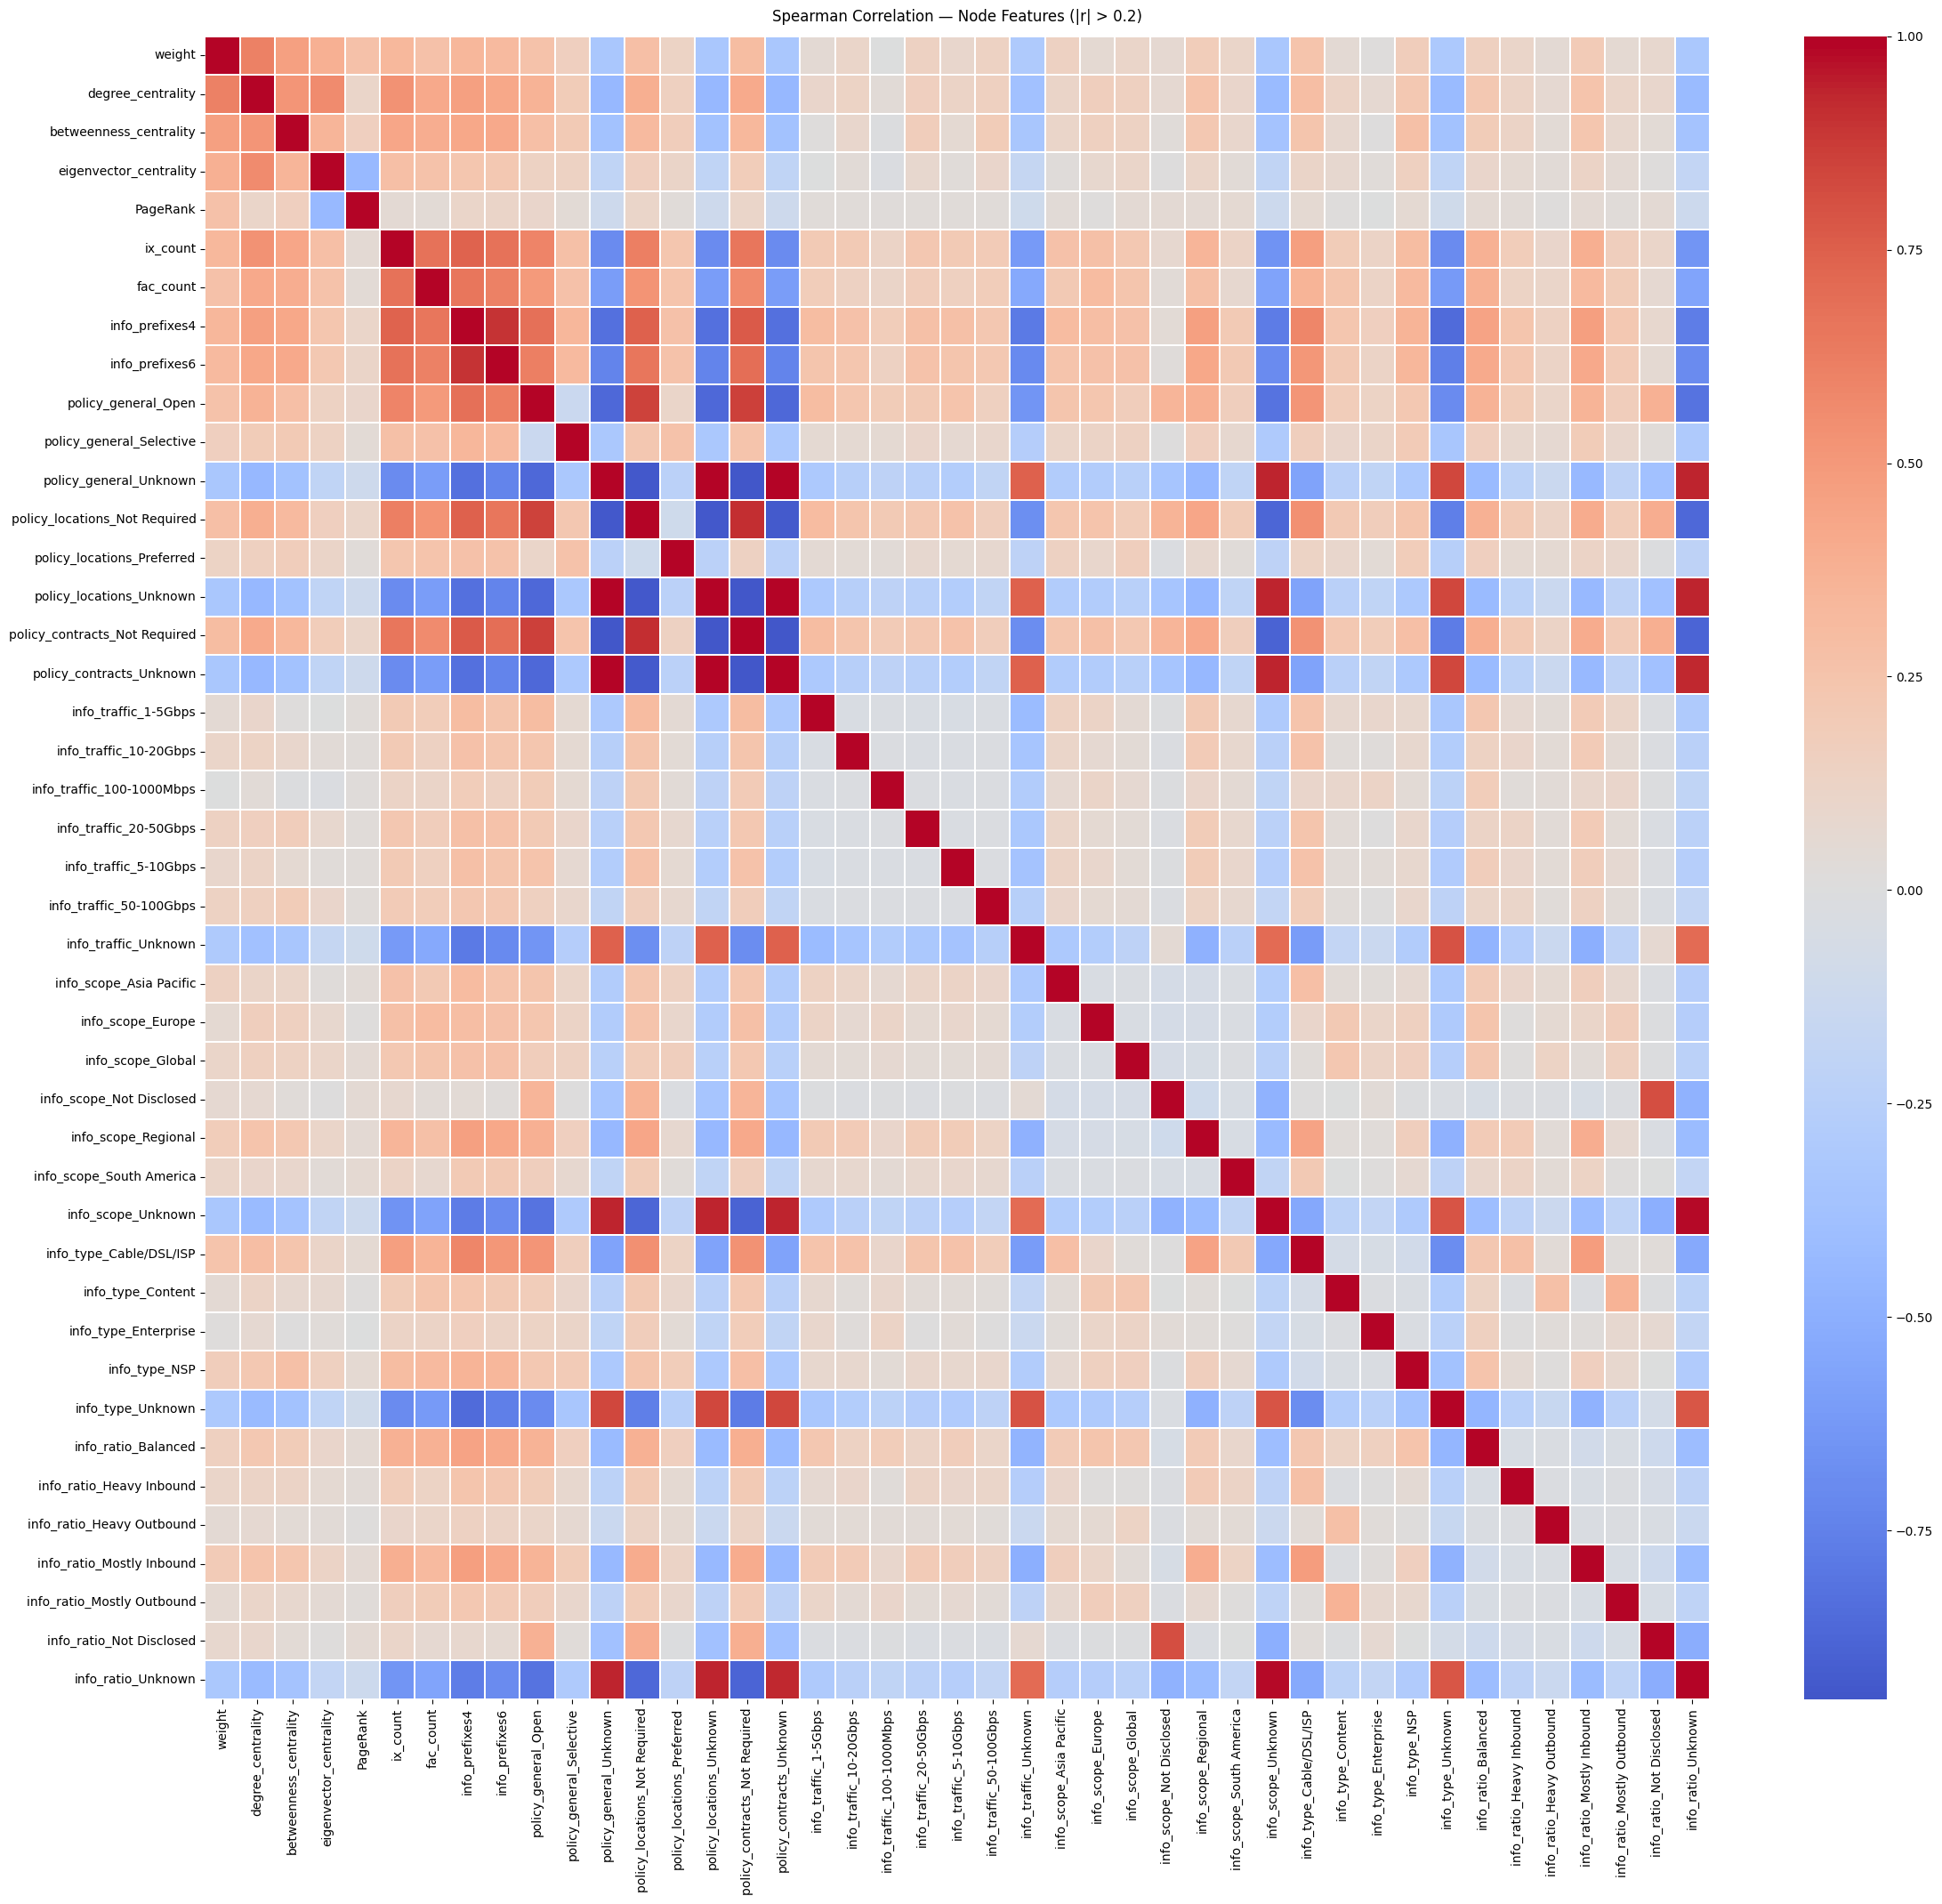

Top 15 strongest correlations (Spearman |r|):


,A,B,r
0,policy_general_Unknown,policy_locations_Unknown,1.000000
1,policy_general_Unknown,policy_contracts_Unknown,0.998071
2,policy_locations_Unknown,policy_contracts_Unknown,0.998071
3,info_scope_Unknown,info_ratio_Unknown,0.982431
4,policy_contracts_Not Required,policy_contracts_Unknown,-0.947435
5,policy_locations_Unknown,policy_contracts_Not Required,-0.945595
6,policy_general_Unknown,policy_contracts_Not Required,-0.945595
7,policy_general_Unknown,info_scope_Unknown,0.939011
8,policy_locations_Unknown,info_scope_Unknown,0.939011
9,policy_contracts_Unknown,info_scope_Unknown,0.937316


In [6]:
num_cols = [c for c in nodes_df.columns
            if c not in META_COLS and pd.api.types.is_numeric_dtype(nodes_df[c])]
corr = nodes_df[num_cols].corr(method='spearman')

# Keep only columns with at least one strong correlation with another column
mask_keep = ((corr.abs() > 0.2).sum() > 1)
corr_f = corr.loc[mask_keep, mask_keep]

fig, ax = plt.subplots(figsize=(max(10, len(corr_f) * 0.55),
                                max(8,  len(corr_f) * 0.5)))
sns.heatmap(corr_f, annot=len(corr_f) <= 20, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.3, ax=ax, annot_kws={'size': 7})
ax.set_title('Spearman Correlation — Node Features (|r| > 0.2)', pad=12)
plt.tight_layout()
plt.show()

# Top pairs
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack()
             .rename_axis(['A', 'B'])
             .reset_index(name='r')
             .sort_values('r', key=abs, ascending=False))
print("Top 15 strongest correlations (Spearman |r|):")
display(pairs.head(15).reset_index(drop=True))

## Feature Distributions by Relationship Type

Each node is assigned its most frequent outgoing relationship type.

In [7]:
REL_MAP    = {0: 'P2P', 1: 'C2P', 2: 'P2C'}
REL_ORDER  = ['P2P', 'C2P', 'P2C']
REL_COLORS = {'P2P': '#2196F3', 'C2P': '#FF9800', 'P2C': '#4CAF50'}

edges_lab = edges_df[edges_df['relationship'].isin([0, 1, 2])].copy()
edges_lab['rel_name'] = edges_lab['relationship'].map(REL_MAP)

dom = (edges_lab.groupby(['src_id', 'rel_name']).size().reset_index(name='n'))
dom = (dom.loc[dom.groupby('src_id')['n'].idxmax()]
           [['src_id', 'rel_name']]
           .rename(columns={'src_id': 'node_id', 'rel_name': 'dominant_rel'}))
nwr = nodes_df.merge(dom, on='node_id', how='inner')
rels_present = [r for r in REL_ORDER if r in nwr['dominant_rel'].unique()]

print("Nodes per dominant relationship type:")
print(nwr['dominant_rel'].value_counts().to_string())

Nodes per dominant relationship type:
dominant_rel
C2P    66463
P2P     9125
P2C     3333


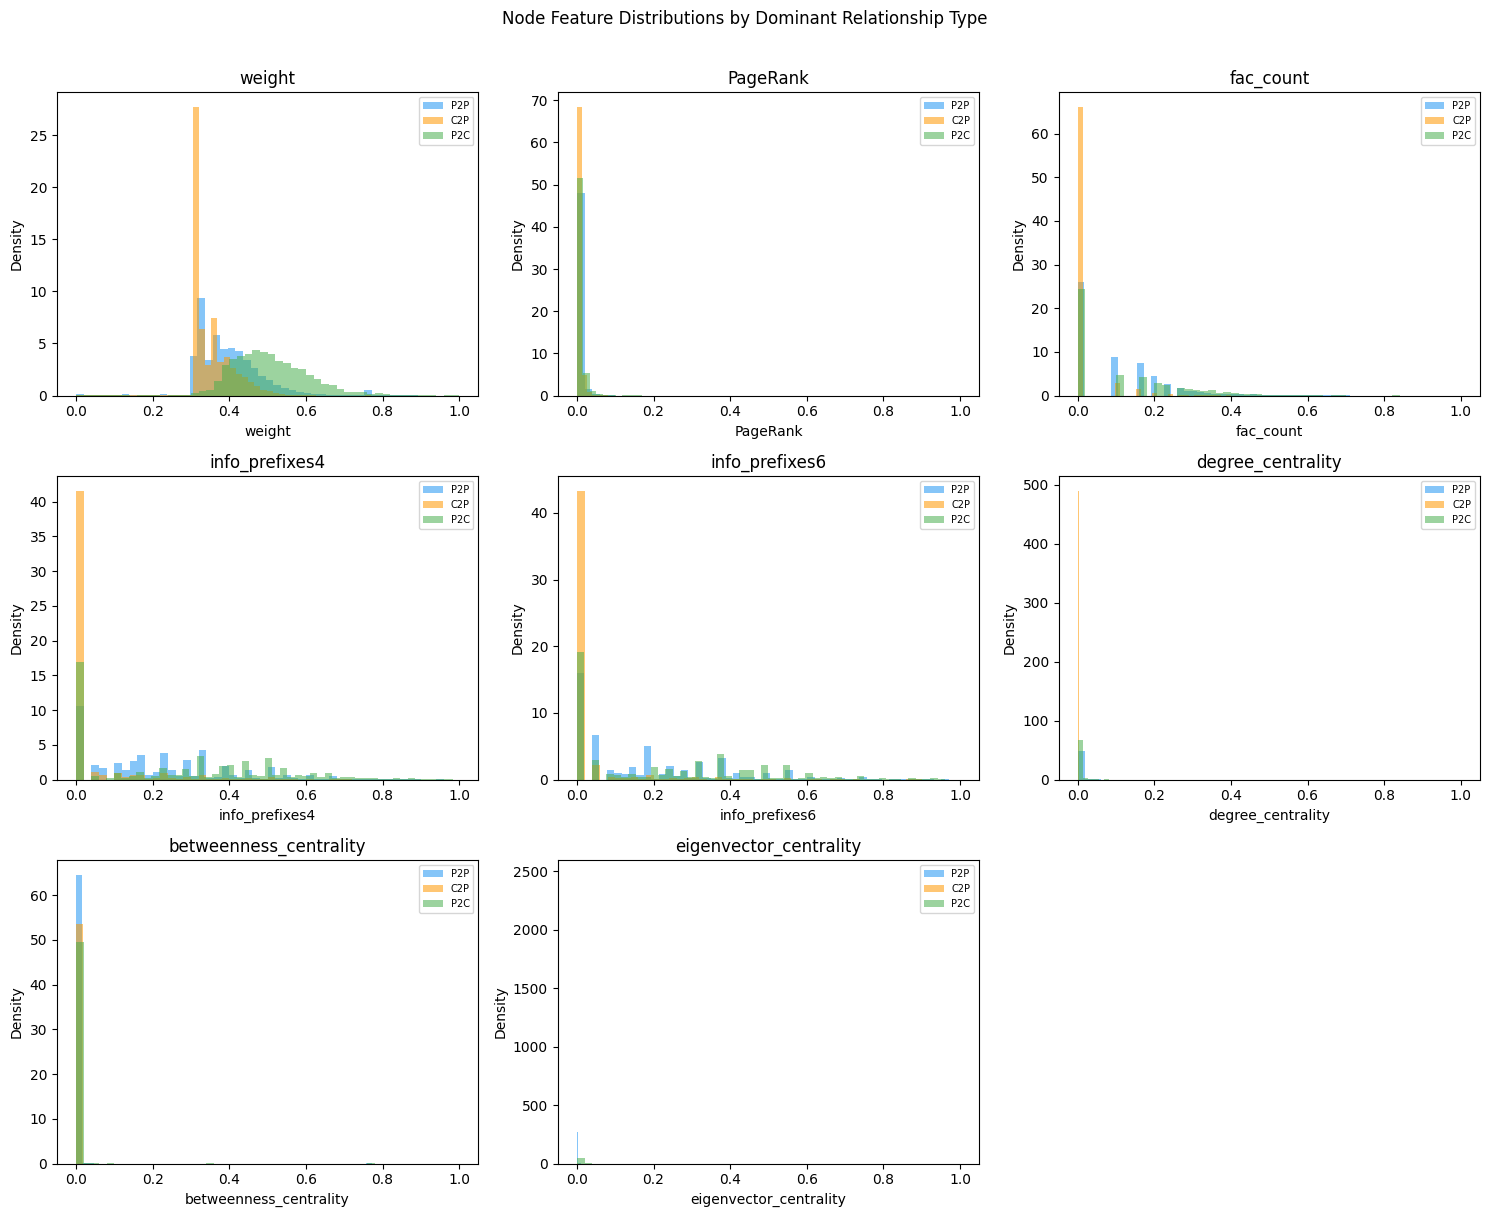

In [8]:
# Continuous feature histograms
KEY_FEATS = ['weight', 'PageRank', 'fac_count', 'info_prefixes4', 'info_prefixes6',
             'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality']
KEY_FEATS = [c for c in KEY_FEATS if c in nwr.columns]

n_cols = 3
n_rows = max(1, (len(KEY_FEATS) + 2) // 3)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(KEY_FEATS):
    ax = axes[i]
    use_log = nwr[col].max(skipna=True) > 1
    for rel in rels_present:
        vals = nwr[nwr['dominant_rel'] == rel][col].dropna()
        vals = np.log1p(vals) if use_log else vals
        ax.hist(vals, bins=50, alpha=0.55, label=rel,
                color=REL_COLORS[rel], density=True)
    ax.set_title(col)
    ax.set_xlabel(f'log1p({col})' if use_log else col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

for j in range(len(KEY_FEATS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Node Feature Distributions by Dominant Relationship Type',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

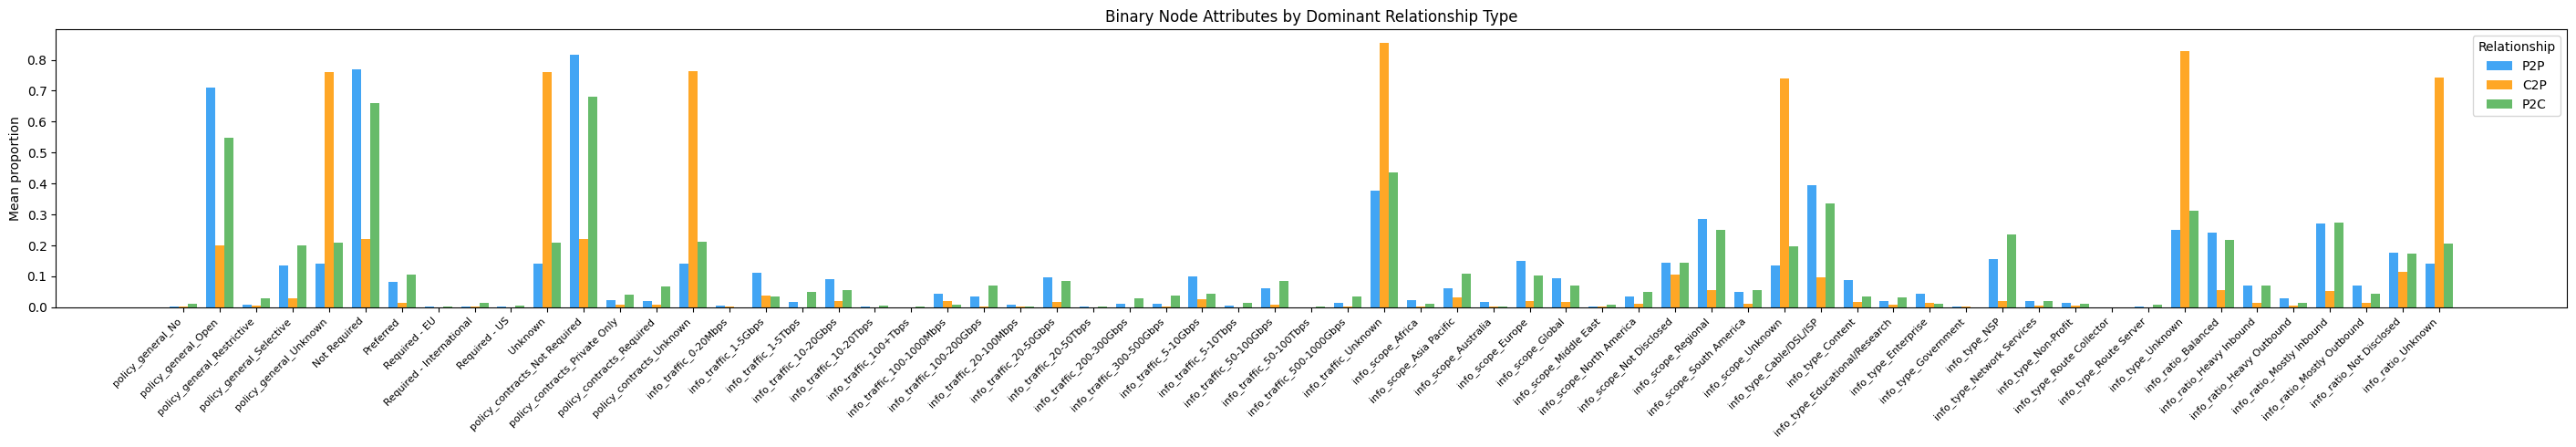

In [9]:
# Binary feature proportions (policy_locations, etc.)
bin_cols = [c for c in nodes_df.columns
            if c not in META_COLS and c not in KEY_FEATS
            and pd.api.types.is_numeric_dtype(nodes_df[c])
            and set(nodes_df[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})
            and nodes_df[c].nunique(dropna=True) == 2]

if bin_cols:
    mean_rel = nwr.groupby('dominant_rel')[bin_cols].mean().loc[rels_present]
    fig, ax = plt.subplots(figsize=(max(14, len(bin_cols) * 0.45), 5))
    x     = np.arange(len(bin_cols))
    width = 0.25
    for k, rel in enumerate(rels_present):
        ax.bar(x + k * width, mean_rel.loc[rel], width,
               label=rel, color=REL_COLORS[rel], alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels([c.replace('policy_locations_', '') for c in bin_cols],
                       rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Mean proportion')
    ax.set_title('Binary Node Attributes by Dominant Relationship Type')
    ax.legend(title='Relationship')
    plt.tight_layout()
    plt.show()
else:
    print("No binary columns found outside KEY_FEATS.")

In [10]:
# Median table
med = nwr.groupby('dominant_rel')[KEY_FEATS].median().loc[rels_present]
print("Median of continuous features per relationship type:")
display(med.style.background_gradient(cmap='Blues', axis=0).format('{:.5f}'))

Median of continuous features per relationship type:


,weight,PageRank,fac_count,info_prefixes4,info_prefixes6,degree_centrality,betweenness_centrality,eigenvector_centrality
dominant_rel,,,,,,,,
P2P,0.38562,0.00046,0.10335,0.19602,0.12908,0.00220,0.00000,0.00005
C2P,0.32448,0.00052,0.00000,0.00000,0.00000,0.00010,0.00000,0.00001
P2C,0.49457,0.00214,0.10335,0.28459,0.19232,0.00136,0.00020,0.00026


## Conclusions

In [11]:
print("=" * 65)
print("ATTRIBUTE INSPECTION — CONCLUSIONS")
print("=" * 65)

# 1. Features outside [0, 1]
bad = attr_table[attr_table['Type'].str.contains('Numeric') &
                 ~attr_table['Type'].str.contains(r'\[0,1\]', regex=True)]
if not bad.empty:
    print(f"\n[!] {len(bad)} feature(s) outside [0,1] — need normalization:")
    for _, r in bad.iterrows():
        print(f"    {r['Attribute']:<38} range [{r['Min']:.3g}, {r['Max']:.3g}]")
else:
    print("\n[OK] All numeric features are within [0, 1].")

# 2. Null columns
nulls = attr_table[attr_table['Null%'] > 0].sort_values('Null%', ascending=False)
if not nulls.empty:
    print(f"\n[!] {len(nulls)} column(s) with missing values:")
    for _, r in nulls.iterrows():
        print(f"    {r['Attribute']:<38} {r['Null%']:.1f}% null")
else:
    print("\n[OK] No missing values found.")

# 3. Strong correlations
strong = pairs[pairs['r'].abs() > 0.5]
print(f"\n[i] Strongly correlated pairs (|r| > 0.5): {len(strong)}")
if not strong.empty:
    for _, r in strong.head(5).iterrows():
        print(f"    {r['A']:<30} <-> {r['B']:<30}  r={r['r']:.3f}")

# 4. Class balance
print(f"\n[i] Edge class balance:")
for rel, cnt in edges_df['relationship'].map(rel_map).value_counts().items():
    pct = cnt / len(edges_df) * 100
    bar = '#' * int(pct / 2)
    print(f"    {rel:<10} {cnt:>8,}  ({pct:5.1f}%)  {bar}")

# 5. Node coverage
covered = dom['node_id'].nunique()
print(f"\n[i] Nodes covered by labeled edges: "
      f"{covered:,} / {len(nodes_df):,}  ({covered/len(nodes_df)*100:.1f}%)")

# 6. PageRank range (for Table 2)
if 'PageRank' in nodes_df.columns:
    pr = nodes_df['PageRank']
    print(f"\n[i] PageRank  min={pr.min():.3e}  max={pr.max():.3e}")
    print(f"    => Table 2 entry: Numeric in [0, {pr.max():.2e}]")

print("\n" + "=" * 65)

ATTRIBUTE INSPECTION — CONCLUSIONS

[OK] All numeric features are within [0, 1].

[OK] No missing values found.

[i] Strongly correlated pairs (|r| > 0.5): 109
    policy_general_Unknown         <-> policy_locations_Unknown        r=1.000
    policy_general_Unknown         <-> policy_contracts_Unknown        r=0.998
    policy_locations_Unknown       <-> policy_contracts_Unknown        r=0.998
    info_scope_Unknown             <-> info_ratio_Unknown              r=0.982
    policy_contracts_Not Required  <-> policy_contracts_Unknown        r=-0.947

[i] Edge class balance:
    P2P         340,512  ( 46.4%)  #######################
    C2P         159,963  ( 21.8%)  ##########
    P2C         159,963  ( 21.8%)  ##########
    Unknown      73,943  ( 10.1%)  #####

[i] Nodes covered by labeled edges: 78,921 / 79,504  (99.3%)

[i] PageRank  min=0.000e+00  max=1.000e+00
    => Table 2 entry: Numeric in [0, 1.00e+00]

